In [1]:
setwd("/home/strawberry/Documents/Masters/coculture/Isa") # change the location to where your csv files are

In [3]:
install.packages("growthcurver")

also installing the dependency ‘minpack.lm’


Warning message in install.packages("growthcurver"):
“installation of package ‘minpack.lm’ had non-zero exit status”
Warning message in install.packages("growthcurver"):
“installation of package ‘growthcurver’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
library(reshape2)
# library(growthcurver)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://con

ERROR: Error in library(reshape2): there is no package called ‘reshape2’


In [6]:
# Process single-point measures

In [16]:
# Read raw file (semicolon/comma decimal issue to handle)
raw <- read.csv("od600_tp0.csv", header = FALSE, skip = 1, na.strings = c("", "NA"))

# Make first column into row names
rownames(raw) <- raw$V1
raw <- raw[, -1]   # drop V1 now that it's row names

# Rename columns as 1–12
colnames(raw) <- as.character(1:12)

print(raw)

   1  2      3      4     5      6     7     8     9    10 11 12
A NA NA   <NA>   <NA>  <NA>   <NA>  <NA>  <NA>  <NA>  <NA> NA NA
B NA NA   <NA>   <NA>  <NA>   <NA>  <NA>  <NA>  <NA>  <NA> NA NA
C NA NA   0,06  0,094 0,053   0,09 0,093 0,087 0,107 0,059 NA NA
D NA NA  0,147  0,057 0,049  0,065 0,047 0,071 0,132 0,074 NA NA
E NA NA  0,093  0,083   0,1   0,07  0,07 0,099 0,079 0,075 NA NA
F NA NA   0,04   0,07 0,046   0,06 0,064 0,038 0,057 0,053 NA NA
G NA NA -0,011 -0,009 0,027 -0,008  <NA>  <NA>  <NA>  <NA> NA NA
H NA NA   <NA>   <NA>  <NA>   <NA>  <NA>  <NA>  <NA>  <NA> NA NA


In [22]:
# Convert rownames into a column
raw2 <- raw %>%
  tibble::rownames_to_column("Row")

# Pivot longer to get Row + Column + Value
long <- raw2 %>%
  pivot_longer(-Row, names_to = "Col", values_to = "Value") %>%
  mutate(Well = paste0(Row, Col)) %>%
  select(Well, Value)

# keep only non-NA values
long <- long %>% filter(!is.na(Value) & Value != "<NA>") 

# Convert decimal commas to numeric with dots
long$Value <- as.numeric(gsub(",", ".", long$Value))

# Transpose into wide format: one row with wells as columns
wide <- long %>%
  pivot_wider(names_from = Well, values_from = Value)

# Add Time column at the front
wide <- wide %>%
  mutate(Time = "00:00:00", .before = 1)

head(wide)

Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.06,0.094,0.053,0.09,0.093,0.087,0.107,0.059,0.147,⋯,0.046,0.06,0.064,0.038,0.057,0.053,-0.011,-0.009,0.027,-0.008


In [19]:
# Process incubation measures

In [21]:
# Load and clean `od600_tp.csv` (replace "," decimal and quotes)
od_tp <- read_csv("od600_tp.csv", na = c("", "NA")) %>%
  mutate(across(
    -Time,
    ~ .x %>%
      str_replace_all(",", ".") %>%   # convert decimal commas to dots
      as.numeric()
  ))
head(od_tp)

Rows: 145 Columns: 37
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (34): C3, C4, C5, C6, C7, C8, C9, C10, D3, D4, D5, D6, D7, D8, D9, D10,...
num   (2): G3, G6
time  (1): Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<time>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:29:35,0.067,0.127,0.073,0.114,0.109,0.103,0.148,0.087,0.167,⋯,0.068,0.083,0.089,0.063,0.079,0.067,-7,-0.007,0.023,-9
00:59:35,0.119,0.210,0.114,0.181,0.145,0.144,0.213,0.147,0.212,⋯,0.101,0.115,0.140,0.099,0.120,0.116,-8,-0.008,0.026,-1
01:29:35,0.209,0.332,0.186,0.222,0.223,0.228,0.333,0.259,0.285,⋯,0.145,0.170,0.198,0.149,0.177,0.168,-11,-0.007,0.025,-7
01:59:35,0.322,0.517,0.310,0.349,0.362,0.368,0.514,0.427,0.376,⋯,0.200,0.236,0.277,0.218,0.250,0.242,-12,-0.007,0.023,-5
02:29:35,0.481,0.717,0.480,0.515,0.549,0.549,0.723,0.622,0.502,⋯,0.269,0.313,0.372,0.297,0.342,0.330,-11,-0.006,0.022,-4
02:59:35,0.641,0.809,0.622,0.633,0.691,0.762,0.913,0.828,0.662,⋯,0.340,0.403,0.495,0.389,0.459,0.435,-11,-0.006,0.021,-3


In [24]:
# Make sure Time columns are both characters
od_tp$Time <- as.character(od_tp$Time)
wide$Time <- as.character(wide$Time)

# Take the first row of formatted_df
first_row <- wide[1, ]

# Bind it on top of od_tp
combined_od <- rbind(first_row, od_tp)
head(combined_od)

Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.060,0.094,0.053,0.090,0.093,0.087,0.107,0.059,0.147,⋯,0.046,0.060,0.064,0.038,0.057,0.053,-0.011,-0.009,0.027,-0.008
00:29:35,0.067,0.127,0.073,0.114,0.109,0.103,0.148,0.087,0.167,⋯,0.068,0.083,0.089,0.063,0.079,0.067,-7.000,-0.007,0.023,-9.000
00:59:35,0.119,0.210,0.114,0.181,0.145,0.144,0.213,0.147,0.212,⋯,0.101,0.115,0.140,0.099,0.120,0.116,-8.000,-0.008,0.026,-1.000
01:29:35,0.209,0.332,0.186,0.222,0.223,0.228,0.333,0.259,0.285,⋯,0.145,0.170,0.198,0.149,0.177,0.168,-11.000,-0.007,0.025,-7.000
01:59:35,0.322,0.517,0.310,0.349,0.362,0.368,0.514,0.427,0.376,⋯,0.200,0.236,0.277,0.218,0.250,0.242,-12.000,-0.007,0.023,-5.000
02:29:35,0.481,0.717,0.480,0.515,0.549,0.549,0.723,0.622,0.502,⋯,0.269,0.313,0.372,0.297,0.342,0.330,-11.000,-0.006,0.022,-4.000


In [54]:
write_tsv(file = "combined_od.tsv", combined_od)

In [28]:
print(head(combined_od))

# A tibble: 6 × 37
  Time      C3    C4    C5    C6    C7    C8    C9   C10    D3    D4    D5    D6
  <chr>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 00:00… 0.06  0.094 0.053 0.09  0.093 0.087 0.107 0.059 0.147 0.057 0.049 0.065
2 00:29… 0.067 0.127 0.073 0.114 0.109 0.103 0.148 0.087 0.167 0.069 0.06  0.081
3 00:59… 0.119 0.21  0.114 0.181 0.145 0.144 0.213 0.147 0.212 0.096 0.12  0.126
4 01:29… 0.209 0.332 0.186 0.222 0.223 0.228 0.333 0.259 0.285 0.146 0.147 0.203
5 01:59… 0.322 0.517 0.31  0.349 0.362 0.368 0.514 0.427 0.376 0.217 0.215 0.286
6 02:29… 0.481 0.717 0.48  0.515 0.549 0.549 0.723 0.622 0.502 0.293 0.294 0.399
# ℹ 24 more variables: D7 <dbl>, D8 <dbl>, D9 <dbl>, D10 <dbl>, E3 <dbl>,
#   E4 <dbl>, E5 <dbl>, E6 <dbl>, E7 <dbl>, E8 <dbl>, E9 <dbl>, E10 <dbl>,
#   F3 <dbl>, F4 <dbl>, F5 <dbl>, F6 <dbl>, F7 <dbl>, F8 <dbl>, F9 <dbl>,
#   F10 <dbl>, G3 <dbl>, G4 <dbl>, G5 <dbl>, G6 <dbl>


In [35]:
# Reshape to long format
combined_long <- combined_od %>%
  pivot_longer(
    cols = -Time,        # all columns except Time
    names_to = "Well",   # new column with well IDs
    values_to = "OD600"     # new column with OD values
  )

# Create a duration column (in hours)
combined_long <- combined_long %>%
  separate(Time, into = c("H", "M", "S"), sep = ":", convert = TRUE) %>%
  mutate(
    Time_hr = H + M / 60 + S / 3600
  ) %>%
  select(-H, -M, -S) %>% # optional: drop split columns
  mutate(Time_hr = as.numeric(hms::as_hms(Time_hr))) # seconds


head(combined_long)

Well,OD600,Time_hr
<chr>,<dbl>,<dbl>
C3,0.060,0
C4,0.094,0
C5,0.053,0
C6,0.090,0
C7,0.093,0
C8,0.087,0


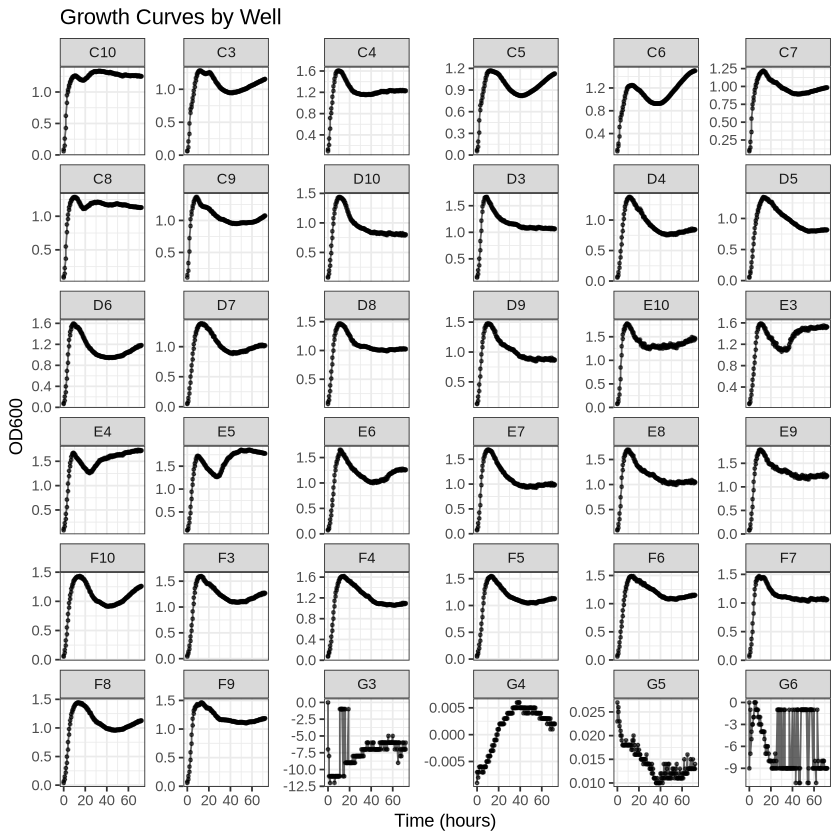

In [38]:
combined_long <- combined_long %>%
  mutate(Well = factor(Well, levels = sort(unique(Well))))

# Plot: dots connected by lines, faceted by Well
ggplot(combined_long, aes(x = round(Time_hr), y = OD600)) +
  geom_point(size = 0.7, alpha = 0.6) +
  geom_line(alpha = 0.6) +
  facet_wrap(~Well, scales = "free_y") +
  labs(
    x = "Time (hours)",
    y = "OD600",
    title = "Growth Curves by Well"
  ) +
  theme_bw()

In [39]:
# Define well groups
AH1253_cols <- c("C3", "C4", "C5", "C6",   # Glucose
                 "D3", "D4", "D5", "D6",   # SIA
                 "E3", "E4", "E5", "E6",   # GMP9000
                 "F3", "F4", "F5", "F6")   # No carbon

AH1956_cols <- c("C7", "C8", "C9", "C10",  # Glucose
                 "D7", "D8", "D9", "D10",  # SIA
                 "E7", "E8", "E9", "E10",  # GMP9000
                 "F7", "F8", "F9", "F10")  # No carbon

blank_cols <- c("G3", "G4", "G5", "G6")

# Map wells to carbon sources
carbon_map <- list(
  CLM = c("F3", "F4", "F5", "F6",   # 1253
           "F7", "F8", "F9", "F10"), # 1956

  CLM_GLU = c("C3", "C4", "C5", "C6",   # 1253
              "C7", "C8", "C9", "C10"), # 1956

  CLM_SIA = c("D3", "D4", "D5", "D6",   # 1253
              "D7", "D8", "D9", "D10"), # 1956

  CLM_GMP9000 = c("E3", "E4", "E5", "E6",   # 1253
                  "E7", "E8", "E9", "E10") # 1956
)

In [45]:
# Add Strain and Carbon source based on your groups
combined_long <- combined_long %>%
  mutate(
    Strain = case_when(
      Well %in% AH1253_cols ~ "AH1253",
      Well %in% AH1956_cols ~ "AH1956",
      TRUE ~ "Other"
    ),
    Carbon = case_when(
      Well %in% carbon_map$CLM ~ "CLM",
      Well %in% carbon_map$CLM_GLU ~ "CLM_GLU",
      Well %in% carbon_map$CLM_SIA ~ "CLM_SIA",
      Well %in% carbon_map$CLM_GMP9000 ~ "CLM_GMP9000",
      TRUE ~ "Blank/Other"
    )
  )

# Quick check of the updated dataframe
head(combined_long)

Well,OD600,Time_hr,Strain,Carbon
<fct>,<dbl>,<dbl>,<chr>,<chr>
C3,0.060,0,AH1253,CLM_GLU
C4,0.094,0,AH1253,CLM_GLU
C5,0.053,0,AH1253,CLM_GLU
C6,0.090,0,AH1253,CLM_GLU
C7,0.093,0,AH1956,CLM_GLU
C8,0.087,0,AH1956,CLM_GLU


In [50]:
# Remove unassigned wells before plotting
combined_long <- combined_long %>%
  filter(Carbon != "Blank/Other")
unique(combined_long$Carbon)

[1] "CLM_GLU"     "CLM_SIA"     "CLM_GMP9000" "CLM"

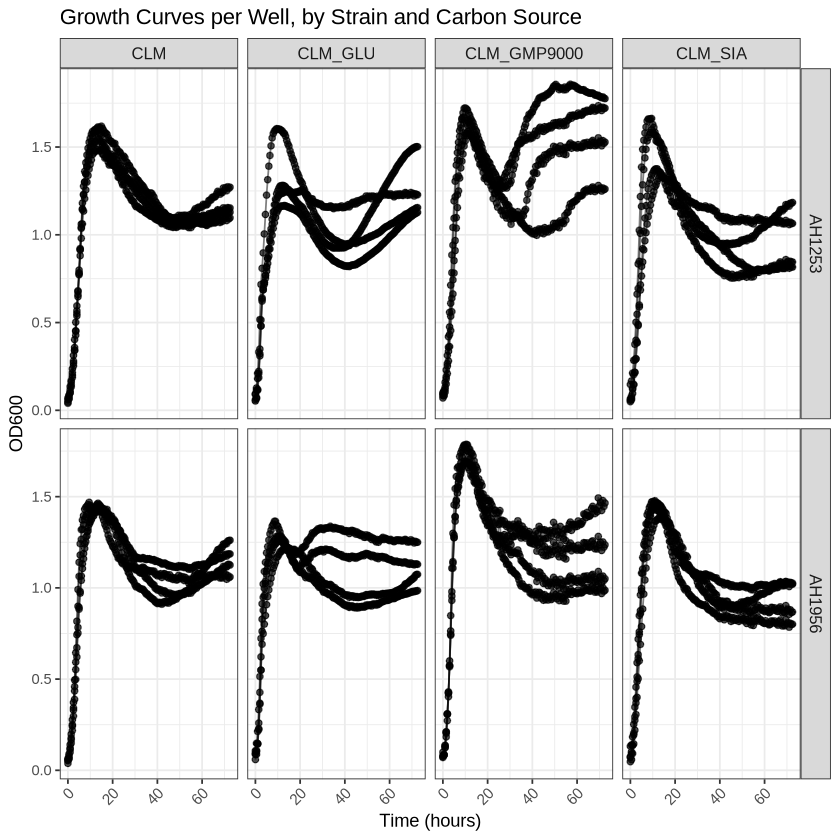

In [52]:
# Plot per carbon source and strain 
ggplot(combined_long, aes(x = Time_hr, y = OD600, group = Well)) +
  geom_point(size = 1.5, alpha = 0.7) +       # raw measurements
  geom_line(alpha = 0.5) +                    # connect points per well
  facet_grid(Strain ~ Carbon, scales = "free_y") +  # rows = Strain, cols = Carbon
  labs(
    x = "Time (hours)",
    y = "OD600",
    title = "Growth Curves per Well, by Strain and Carbon Source"
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 10)
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


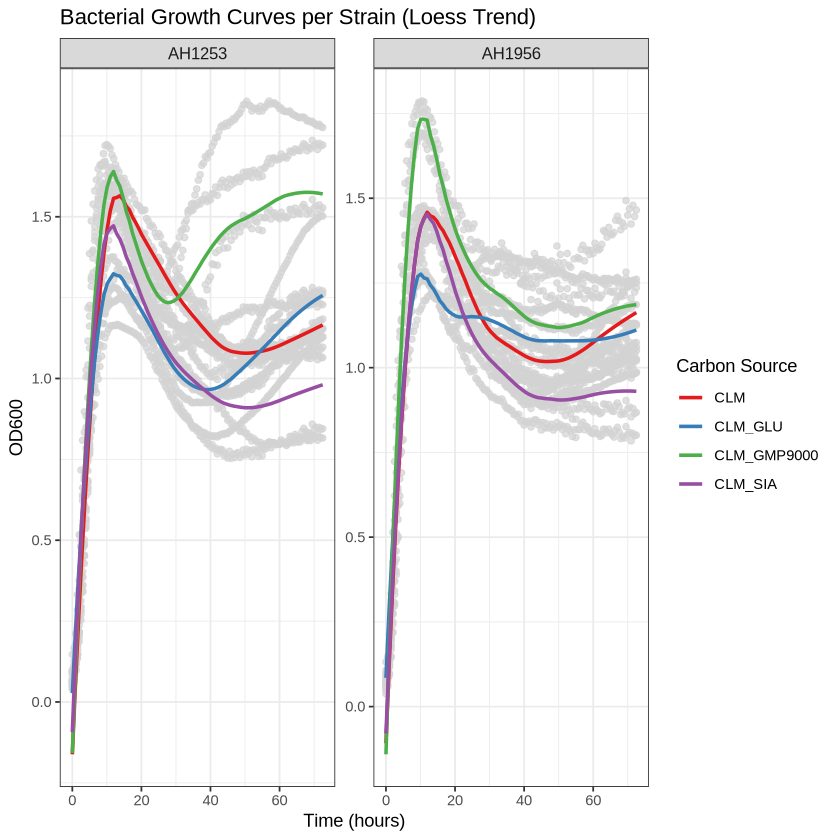

In [53]:
ggplot(combined_long, aes(x = Time_hr, y = OD600)) +
  # Raw measurements in light gray
  geom_point(aes(group = Well), color = "lightgray", size = 1.5, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = Carbon, group = Carbon), method = "loess", span = 0.3, se = FALSE, size = 1) +
  facet_wrap(~Strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (hours)",
    y = "OD600",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Trend)"
  ) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10)
  )

`geom_smooth()` using formula = 'y ~ x'


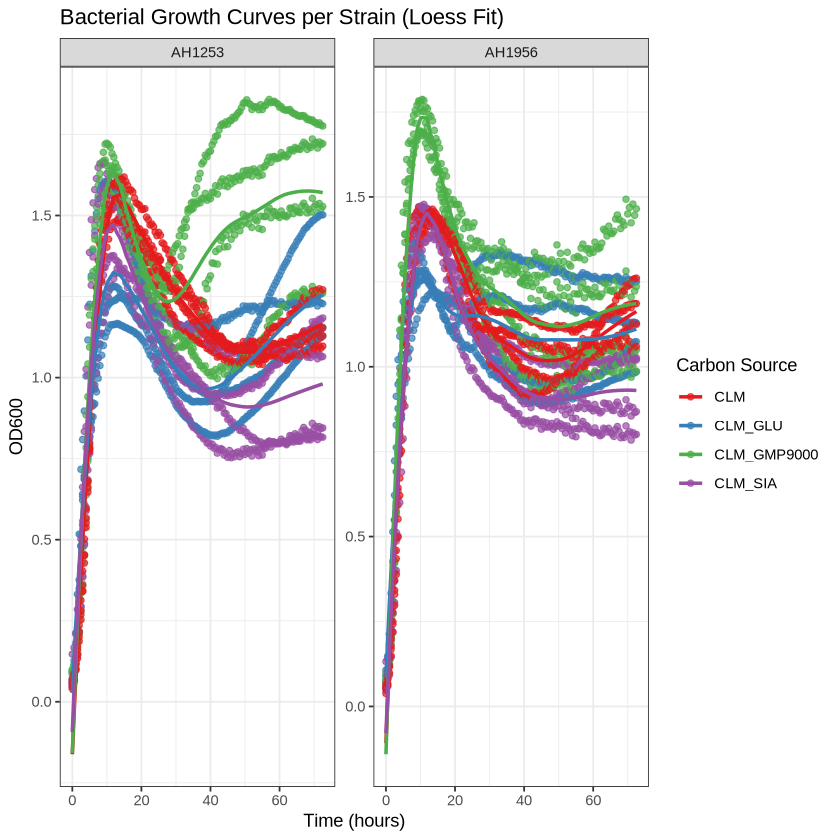

In [51]:
ggplot(combined_long, aes(x = Time_hr, y = OD600, color = Carbon)) +
  geom_point(size = 1.5, alpha = 0.7) +        # raw measurements
  geom_smooth(method = "loess", span = 0.3, se = FALSE, aes(group = Carbon)) +  # smoothed trend
  facet_wrap(~Strain, scales = "free_y") +     # one panel per isolate
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (hours)",
    y = "OD600",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Fit)"
  ) +
  theme_bw()

In [55]:
install.packages("gcplyr")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [56]:
library(gcplyr)

library(dplyr)
library(ggplot2)

## 
## gcplyr (Version 1.12.0, Build Date: 2025-07-28)
## See http://github.com/mikeblazanin/gcplyr for additional documentation
## Please cite software as:
##   Blazanin, Michael. gcplyr: an R package for microbial growth
##   curve data analysis. BMC Bioinformatics 25, 232 (2024).
##   https://doi.org/10.1186/s12859-024-05817-3
## 




Files have been written



[1] "./widedata.csv"

Files have been written



[1] "./Bacteria_strain.csv" "./Phage.csv"

Inferred 'into' column names as: Bacteria_strain, Phage

Joining with `by = join_by(Well)`


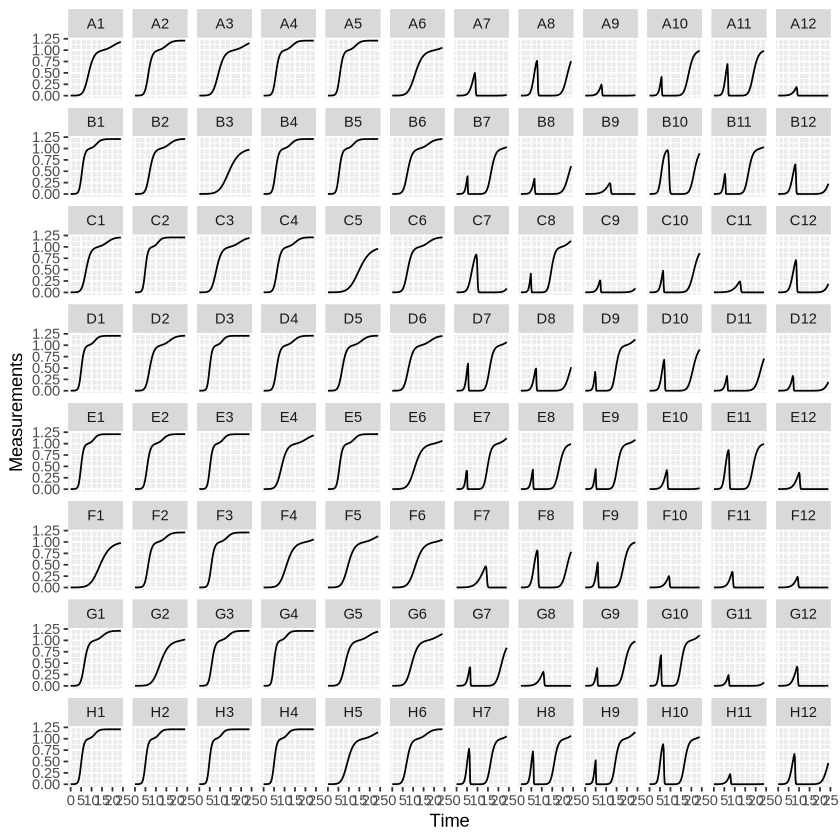

In [57]:
#For the purposes of this demo, we have to create our example data and
# design files. Normally, the data file would be created by a plate reader, and
# the design file would be created by you, the user

#Generate our example data file, widedata.csv
make_example(vignette = 1, example = 1)

#Generate our example design files, Bacteria_strain.csv and Phage.csv
make_example(vignette = 1, example = 2)

# Read in our data 
data_wide <- read_wides(files = "widedata.csv")

# Transform our data to be tidy-shaped
data_tidy <- 
  trans_wide_to_tidy(wides = data_wide, id_cols = c("file", "Time"))

# Convert our time into hours
data_tidy$Time <- as.numeric(data_tidy$Time)/3600

# Import our designs
designs <- import_blockdesigns(files = c("Bacteria_strain.csv", "Phage.csv"))

# Merge our designs and data
data_merged <- merge_dfs(data_tidy, designs)

#Set up the Well column so they plot in the correct order
data_merged$Well <- 
  factor(data_merged$Well,
         levels = paste0(rep(LETTERS[1:8], each = 12), 1:12))

#Plot the data
ggplot(data = data_merged, aes(x = Time, y = Measurements)) +
  geom_line() +
  facet_wrap(~Well, nrow = 8, ncol = 12)

In [115]:
################################################################################## fuck my huge asshole fuck 

### Process single-point measures

In [67]:
# Read raw file (semicolon/comma decimal issue to handle)
raw <- read.csv("od600_tp0.csv", header = FALSE, skip = 1, na.strings = c("", "NA"))

# Make first column into row names
rownames(raw) <- raw$V1
raw <- raw[, -1]   # drop V1 now that it's row names

# Rename columns as 1–12
colnames(raw) <- as.character(1:12)

head(raw)
# Convert rownames into a column
raw2 <- raw %>%
  tibble::rownames_to_column("Row")

# Pivot longer to get Row + Column + Value
long <- raw2 %>%
  pivot_longer(-Row, names_to = "Col", values_to = "Value") %>%
  mutate(Well = paste0(Row, Col)) %>%
  select(Well, Value)

# keep only non-NA values
long <- long %>% filter(!is.na(Value) & Value != "<NA>") 

# Convert decimal commas to numeric with dots
long$Value <- as.numeric(gsub(",", ".", long$Value))

# Transpose into wide format: one row with wells as columns
wide <- long %>%
  pivot_wider(names_from = Well, values_from = Value)

# Add Time column at the front
wide <- wide %>%
  mutate(Time = "00:00:00", .before = 1)

head(wide)

,1,2,3,4,5,6,7,8,9,10,11,12
,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>
A,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
B,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
C,NA,NA,"0,06","0,094","0,053","0,09","0,093","0,087","0,107","0,059",NA,NA
D,NA,NA,"0,147","0,057","0,049","0,065","0,047","0,071","0,132","0,074",NA,NA
E,NA,NA,"0,093","0,083","0,1","0,07","0,07","0,099","0,079","0,075",NA,NA
F,NA,NA,"0,04","0,07","0,046","0,06","0,064","0,038","0,057","0,053",NA,NA


Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.06,0.094,0.053,0.09,0.093,0.087,0.107,0.059,0.147,⋯,0.046,0.06,0.064,0.038,0.057,0.053,-0.011,-0.009,0.027,-0.008


In [68]:
# Process incubation measures
# Load and clean `od600_tp.csv` (replace "," decimal and quotes)
od_tp <- read_csv("od600_tp.csv", na = c("", "NA")) %>%
  mutate(across(
    -Time,
    ~ .x %>%
      str_replace_all(",", ".") %>%   # convert decimal commas to dots
      as.numeric()
  ))
head(od_tp)

# Make sure Time columns are both characters
od_tp$Time <- as.character(od_tp$Time)
wide$Time <- as.character(wide$Time)

# Take the first row of formatted_df
first_row <- wide[1, ]

# Bind it on top of od_tp
combined_od <- rbind(first_row, od_tp)
head(combined_od)

Rows: 145 Columns: 37
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (34): C3, C4, C5, C6, C7, C8, C9, C10, D3, D4, D5, D6, D7, D8, D9, D10,...
num   (2): G3, G6
time  (1): Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<time>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:29:35,0.067,0.127,0.073,0.114,0.109,0.103,0.148,0.087,0.167,⋯,0.068,0.083,0.089,0.063,0.079,0.067,-7,-0.007,0.023,-9
00:59:35,0.119,0.210,0.114,0.181,0.145,0.144,0.213,0.147,0.212,⋯,0.101,0.115,0.140,0.099,0.120,0.116,-8,-0.008,0.026,-1
01:29:35,0.209,0.332,0.186,0.222,0.223,0.228,0.333,0.259,0.285,⋯,0.145,0.170,0.198,0.149,0.177,0.168,-11,-0.007,0.025,-7
01:59:35,0.322,0.517,0.310,0.349,0.362,0.368,0.514,0.427,0.376,⋯,0.200,0.236,0.277,0.218,0.250,0.242,-12,-0.007,0.023,-5
02:29:35,0.481,0.717,0.480,0.515,0.549,0.549,0.723,0.622,0.502,⋯,0.269,0.313,0.372,0.297,0.342,0.330,-11,-0.006,0.022,-4
02:59:35,0.641,0.809,0.622,0.633,0.691,0.762,0.913,0.828,0.662,⋯,0.340,0.403,0.495,0.389,0.459,0.435,-11,-0.006,0.021,-3


Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.060,0.094,0.053,0.090,0.093,0.087,0.107,0.059,0.147,⋯,0.046,0.060,0.064,0.038,0.057,0.053,-0.011,-0.009,0.027,-0.008
00:29:35,0.067,0.127,0.073,0.114,0.109,0.103,0.148,0.087,0.167,⋯,0.068,0.083,0.089,0.063,0.079,0.067,-7.000,-0.007,0.023,-9.000
00:59:35,0.119,0.210,0.114,0.181,0.145,0.144,0.213,0.147,0.212,⋯,0.101,0.115,0.140,0.099,0.120,0.116,-8.000,-0.008,0.026,-1.000
01:29:35,0.209,0.332,0.186,0.222,0.223,0.228,0.333,0.259,0.285,⋯,0.145,0.170,0.198,0.149,0.177,0.168,-11.000,-0.007,0.025,-7.000
01:59:35,0.322,0.517,0.310,0.349,0.362,0.368,0.514,0.427,0.376,⋯,0.200,0.236,0.277,0.218,0.250,0.242,-12.000,-0.007,0.023,-5.000
02:29:35,0.481,0.717,0.480,0.515,0.549,0.549,0.723,0.622,0.502,⋯,0.269,0.313,0.372,0.297,0.342,0.330,-11.000,-0.006,0.022,-4.000


In [69]:
# Define well groups
AH1253_cols <- c("C3", "C4", "C5", "C6",   # Glucose
                 "D3", "D4", "D5", "D6",   # SIA
                 "E3", "E4", "E5", "E6",   # GMP9000
                 "G3", "G4", "G5", "G6")   # No carbon

AH1956_cols <- c("C7", "C8", "C9", "C10",  # Glucose
                 "D7", "D8", "D9", "D10",  # SIA
                 "E7", "E8", "E9", "E10",  # GMP9000
                 "G7", "G8", "G9", "G10")  # No carbon

blank_cols <- c("F3", "F4", "F5")

# Map wells to carbon sources
carbon_map <- list(
  CLM = c("G3", "G4", "G5", "G6",   # 1253
          "G7", "G8", "G9", "G10"), # 1956

  CLM_GLU = c("C3", "C4", "C5", "C6",   # 1253
              "C7", "C8", "C9", "C10"), # 1956

  CLM_SIA = c("D3", "D4", "D5", "D6",   # 1253
              "D7", "D8", "D9", "D10"), # 1956

  CLM_GMP9000 = c("E3", "E4", "E5", "E6",   # 1253
                  "E7", "E8", "E9", "E10") # 1956
)

In [112]:
# Reshape to long format
od_long <- combined_od %>%
  pivot_longer(
    cols = -Time,
    names_to = "well",
    values_to = "OD600"
  )

# Create metadata: assign strain + carbon_source based on well mapping
od_long <- od_long %>%
  mutate(
    strain = case_when(
      well %in% AH1253_cols ~ "1253",
      well %in% AH1956_cols ~ "1956",
      well %in% blank_cols ~ "Blank",
      TRUE ~ "Unknown"
    ),
    carbon_source = case_when(
      well %in% carbon_map$CLM ~ "CLM",
      well %in% carbon_map$CLM_GLU ~ "CLM_GLU",
      well %in% carbon_map$CLM_SIA ~ "CLM_SIA",
      well %in% carbon_map$CLM_GMP9000 ~ "CLM_GMP9000",
      well %in% blank_cols ~ "Blank",
      TRUE ~ "Unknown"
    )
  )

head(od_long)

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,C3,0.060,1253,CLM_GLU
00:00:00,C4,0.094,1253,CLM_GLU
00:00:00,C5,0.053,1253,CLM_GLU
00:00:00,C6,0.090,1253,CLM_GLU
00:00:00,C7,0.093,1956,CLM_GLU
00:00:00,C8,0.087,1956,CLM_GLU


In [113]:
blank_data <- od_long %>%
  filter(well %in% blank_cols)
head(blank_data)

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,F3,0.040,Blank,Blank
00:00:00,F4,0.070,Blank,Blank
00:00:00,F5,0.046,Blank,Blank
00:29:35,F3,0.065,Blank,Blank
00:29:35,F4,0.086,Blank,Blank
00:29:35,F5,0.068,Blank,Blank


In [106]:
unique(od_long$carbon_source)

[1] "CLM_GLU"     "CLM_SIA"     "CLM_GMP9000" "Blank"       "CLM"

In [107]:
od_long <- od_long %>%
  filter(carbon_source != "Unknown")
unique(od_long$carbon_source)

head(od_long)

[1] "CLM_GLU"     "CLM_SIA"     "CLM_GMP9000" "Blank"       "CLM"

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,C3,0.060,1253,CLM_GLU
00:00:00,C4,0.094,1253,CLM_GLU
00:00:00,C5,0.053,1253,CLM_GLU
00:00:00,C6,0.090,1253,CLM_GLU
00:00:00,C7,0.093,1956,CLM_GLU
00:00:00,C8,0.087,1956,CLM_GLU


In [114]:
write_tsv(file = "blank_data.tsv", blank_data)

In [93]:
# All negative OD values will turn into 0 
od_long2 <- od_long %>%
  mutate(OD600 = pmax(OD600, 0))
head(od_long2)

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,C3,0.060,1253,CLM_GLU
00:00:00,C4,0.094,1253,CLM_GLU
00:00:00,C5,0.053,1253,CLM_GLU
00:00:00,C6,0.090,1253,CLM_GLU
00:00:00,C7,0.093,1956,CLM_GLU
00:00:00,C8,0.087,1956,CLM_GLU


In [94]:
# Convert time to a pure numeric value (in hours)
od_long2$Time <- time_length(hms(od_long2$Time), unit = "hour")

In [117]:
###############################################################3 fuck my life start here 

In [2]:
getwd()

[1] "/home/strawperry/Documents/Masters/growth_curves"

In [4]:
# Set your working directory
# setwd("/home/strawberry/Documents/Masters/coculture/Isa") # change the location to where your csv files are

# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)

# library(growthcurver)

In [1]:
raw <- read.csv("od600_tp0.csv", header = FALSE , skip = 1, na.strings = c("", "NA"))
head(raw)

Warning message in file(file, "rt"):
“cannot open file 'od600_tp0.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [6]:
# Make first column into row names
rownames(raw) <- raw$V1
raw <- raw[, -1]   # drop V1 now that it's row names

# Rename columns as 1–12
colnames(raw) <- as.character(1:12)

head(raw)
# Convert rownames into a column
raw2 <- raw %>%
  tibble::rownames_to_column("Row")

# Pivot longer to get Row + Column + Value
long <- raw2 %>%
  pivot_longer(-Row, names_to = "Col", values_to = "Value") %>%
  mutate(Well = paste0(Row, Col)) %>%
  select(Well, Value)

# keep only non-NA values
long <- long %>% filter(!is.na(Value) & Value != "<NA>") 

head(long)

,1,2,3,4,5,6,7,8,9,10,11,12
,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>
A,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
B,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
C,NA,NA,"0,006","0,009","0,025","-0,011","-0,01","0,005","0,031","0,02",NA,NA
D,NA,NA,"0,016","-0,001","0,012","-0,013","-0,019","0,031","0,028","0,008",NA,NA
E,NA,NA,"0,019","0,009","0,014","0,017","0,009","0,025","0,043","0,013",NA,NA
F,NA,NA,"0,042","0,023","0,009","0,01","0,046","0,014","0,015","0,031",NA,NA


Well,Value
<chr>,<chr>
C3,"0,006"
C4,"0,009"
C5,"0,025"
C6,"-0,011"
C7,"-0,01"
C8,"0,005"


In [7]:
# Convert decimal commas to numeric with dots
long$Value <- as.numeric(gsub(",", ".", long$Value))

# Transpose into wide format: one row with wells as columns
wide <- long %>%
  pivot_wider(names_from = Well, values_from = Value)

# Add Time column at the front
wide <- wide %>%
  mutate(Time = "00:00:00", .before = 1)

head(wide)

Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.006,0.009,0.025,-0.011,-0.01,0.005,0.031,0.02,0.016,⋯,0.009,0.01,0.046,0.014,0.015,0.031,-0.012,0.038,-0.009,-0.017


In [8]:
# i copied and pasted the OD corrigida pra 1 cm table into a notebook and saved it as tsv

In [9]:
od_tp <- read_tsv("od600_tp.tsv", col_types = cols(.default = "c"))
od_tp <- od_tp %>%
  mutate(across(-Time, ~ as.numeric(gsub(",", ".", .))))

head(od_tp)

Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:29:35,0.015,0.021,0.031,-0.013,-0.011,0.023,0.036,0.042,0.014,⋯,0.015,0.011,0.087,0.036,0.046,0.037,-0.012,0.039,-0.008,-0.019
00:59:35,0.017,0.022,0.034,-0.014,-0.012,0.027,0.039,0.053,0.015,⋯,0.015,0.008,0.092,0.038,0.044,0.040,-0.013,0.043,-0.010,-0.020
01:29:35,0.022,0.027,0.040,-0.014,-0.013,0.035,0.051,0.060,0.016,⋯,0.017,0.010,0.101,0.046,0.050,0.047,-0.014,0.044,-0.010,-0.020
01:59:35,0.028,0.050,0.045,-0.014,-0.014,0.047,0.091,0.140,0.018,⋯,0.020,0.013,0.115,0.053,0.074,0.056,-0.014,0.045,-0.010,-0.021
02:29:35,0.049,0.083,0.056,-0.014,-0.014,0.103,0.111,0.140,0.022,⋯,0.024,0.017,0.150,0.065,0.072,0.069,-0.014,0.045,-0.010,-0.021
02:59:35,0.088,0.087,0.082,-0.014,-0.014,0.124,0.129,0.161,0.026,⋯,0.029,0.041,0.199,0.080,0.086,0.083,-0.014,0.044,-0.009,-0.021


In [10]:
# Take the first row of formatted_df
first_row <- wide[1, ]

# Bind it on top of od_tp
combined_od <- rbind(first_row, od_tp)
head(combined_od)

Time,C3,C4,C5,C6,C7,C8,C9,C10,D3,⋯,F5,F6,F7,F8,F9,F10,G3,G4,G5,G6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:00:00,0.006,0.009,0.025,-0.011,-0.010,0.005,0.031,0.020,0.016,⋯,0.009,0.010,0.046,0.014,0.015,0.031,-0.012,0.038,-0.009,-0.017
00:29:35,0.015,0.021,0.031,-0.013,-0.011,0.023,0.036,0.042,0.014,⋯,0.015,0.011,0.087,0.036,0.046,0.037,-0.012,0.039,-0.008,-0.019
00:59:35,0.017,0.022,0.034,-0.014,-0.012,0.027,0.039,0.053,0.015,⋯,0.015,0.008,0.092,0.038,0.044,0.040,-0.013,0.043,-0.010,-0.020
01:29:35,0.022,0.027,0.040,-0.014,-0.013,0.035,0.051,0.060,0.016,⋯,0.017,0.010,0.101,0.046,0.050,0.047,-0.014,0.044,-0.010,-0.020
01:59:35,0.028,0.050,0.045,-0.014,-0.014,0.047,0.091,0.140,0.018,⋯,0.020,0.013,0.115,0.053,0.074,0.056,-0.014,0.045,-0.010,-0.021
02:29:35,0.049,0.083,0.056,-0.014,-0.014,0.103,0.111,0.140,0.022,⋯,0.024,0.017,0.150,0.065,0.072,0.069,-0.014,0.045,-0.010,-0.021


In [11]:
# Define well groups
AH1253_cols <- c("C3", "C4", "C5", "C6",   # Glucose
                 "D3", "D4", "D5", "D6",   # SIA
                 "E3", "E4", "E5", "E6",   # GMP9000
                 "F3", "F4", "F5", "F6")   # No carbon

AH1956_cols <- c("C7", "C8", "C9", "C10",  # Glucose
                 "D7", "D8", "D9", "D10",  # SIA
                 "E7", "E8", "E9", "E10",  # GMP9000
                 "F7", "F8", "F9", "F10")  # No carbon

blank_cols <- c("G3", "G4", "G5", "G6")

# Map wells to carbon sources
carbon_map <- list(
  CLM = c("F3", "F4", "F5", "F6",   # 1253
          "F7", "F8", "F9", "F10"), # 1956

  CLM_GLU = c("C3", "C4", "C5", "C6",   # 1253
              "C7", "C8", "C9", "C10"), # 1956

  CLM_SIA = c("D3", "D4", "D5", "D6",   # 1253
              "D7", "D8", "D9", "D10"), # 1956

  CLM_GMP9000 = c("E3", "E4", "E5", "E6",   # 1253
                  "E7", "E8", "E9", "E10") # 1956
)

In [12]:
# Reshape to long format
od_long <- combined_od %>%
  pivot_longer(
    cols = -Time,
    names_to = "well",
    values_to = "OD600"
  )

# Create metadata: assign strain + carbon_source based on well mapping
od_long <- od_long %>%
  mutate(
    strain = case_when(
      well %in% AH1253_cols ~ "1253",
      well %in% AH1956_cols ~ "1956",
      well %in% blank_cols ~ "Blank",
      TRUE ~ "Unknown"
    ),
    carbon_source = case_when(
      well %in% carbon_map$CLM ~ "CLM",
      well %in% carbon_map$CLM_GLU ~ "CLM_GLU",
      well %in% carbon_map$CLM_SIA ~ "CLM_SIA",
      well %in% carbon_map$CLM_GMP9000 ~ "CLM_GMP9000",
      well %in% blank_cols ~ "Blank",
      TRUE ~ "Unknown"
    )
  )

head(od_long)

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,C3,0.006,1253,CLM_GLU
00:00:00,C4,0.009,1253,CLM_GLU
00:00:00,C5,0.025,1253,CLM_GLU
00:00:00,C6,-0.011,1253,CLM_GLU
00:00:00,C7,-0.010,1956,CLM_GLU
00:00:00,C8,0.005,1956,CLM_GLU


In [13]:
blank_data <- od_long %>%
  filter(well %in% blank_cols)
head(blank_data)

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,G3,-0.012,Blank,Blank
00:00:00,G4,0.038,Blank,Blank
00:00:00,G5,-0.009,Blank,Blank
00:00:00,G6,-0.017,Blank,Blank
00:29:35,G3,-0.012,Blank,Blank
00:29:35,G4,0.039,Blank,Blank


In [14]:
unique(od_long$carbon_source)

[1] "CLM_GLU"     "CLM_SIA"     "CLM_GMP9000" "CLM"         "Blank"

In [14]:
od_long <- od_long %>%
  filter(carbon_source != "Unknown")
unique(od_long$carbon_source)

head(od_long)

[1] "CLM_GLU"     "CLM_SIA"     "CLM_GMP9000" "CLM"         "Blank"

Time,well,OD600,strain,carbon_source
<chr>,<chr>,<dbl>,<chr>,<chr>
00:00:00,C3,0.453,1253,CLM_GLU
00:00:00,C4,0.143,1253,CLM_GLU
00:00:00,C5,0.098,1253,CLM_GLU
00:00:00,C6,0.058,1253,CLM_GLU
00:00:00,C7,0.044,1956,CLM_GLU
00:00:00,C8,0.012,1956,CLM_GLU


In [15]:
# Convert time to pure numeric value (hours) 
od_long$Time <- time_length(hms(od_long$Time), unit = "hour")
tail(od_long)

Time,well,OD600,strain,carbon_source
<dbl>,<chr>,<dbl>,<chr>,<chr>
72.49306,F9,1.371,1956,CLM
72.49306,F10,1.182,1956,CLM
72.49306,G3,-0.008,Blank,Blank
72.49306,G4,0.036,Blank,Blank
72.49306,G5,-0.010,Blank,Blank
72.49306,G6,-0.019,Blank,Blank


In [16]:
# Convert both Time and OD600 to numeric
od_long <- od_long %>%
  mutate(
    Time = as.numeric(Time),  # convert Time to hours
    OD600 = as.numeric(OD600)             # ensure OD600 is numeric
  )
head(od_long)

tail(od_long)

Time,well,OD600,strain,carbon_source
<dbl>,<chr>,<dbl>,<chr>,<chr>
0,C3,0.006,1253,CLM_GLU
0,C4,0.009,1253,CLM_GLU
0,C5,0.025,1253,CLM_GLU
0,C6,-0.011,1253,CLM_GLU
0,C7,-0.010,1956,CLM_GLU
0,C8,0.005,1956,CLM_GLU


Time,well,OD600,strain,carbon_source
<dbl>,<chr>,<dbl>,<chr>,<chr>
72.49306,F9,1.371,1956,CLM
72.49306,F10,1.182,1956,CLM
72.49306,G3,-0.008,Blank,Blank
72.49306,G4,0.036,Blank,Blank
72.49306,G5,-0.010,Blank,Blank
72.49306,G6,-0.019,Blank,Blank


In [17]:
print(head(od_long))

# A tibble: 6 × 5
   Time well  OD600 strain carbon_source
  <dbl> <chr> <dbl> <chr>  <chr>        
1     0 C3    0.453 1253   CLM_GLU      
2     0 C4    0.143 1253   CLM_GLU      
3     0 C5    0.098 1253   CLM_GLU      
4     0 C6    0.058 1253   CLM_GLU      
5     0 C7    0.044 1956   CLM_GLU      
6     0 C8    0.012 1956   CLM_GLU      


In [17]:
# Calculate mean of all blank wells across all timepoints
mean_blank <- mean(od_long %>% 
                     filter(strain == "Blank", carbon_source == "Blank") %>% 
                     pull(OD600), 
                   na.rm = TRUE)
mean_blank

# Subtract this mean from all OD600 measurements
od_long2 <- od_long %>%
  mutate(OD600_corrected = OD600 - mean_blank)

# Check
head(od_long2)

tail(od_long2)

[1] 5.136986e-06

Time,well,OD600,strain,carbon_source,OD600_corrected
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
0,C3,0.006,1253,CLM_GLU,0.005994863
0,C4,0.009,1253,CLM_GLU,0.008994863
0,C5,0.025,1253,CLM_GLU,0.024994863
0,C6,-0.011,1253,CLM_GLU,-0.011005137
0,C7,-0.010,1956,CLM_GLU,-0.010005137
0,C8,0.005,1956,CLM_GLU,0.004994863


Time,well,OD600,strain,carbon_source,OD600_corrected
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
72.49306,F9,1.371,1956,CLM,1.370994863
72.49306,F10,1.182,1956,CLM,1.181994863
72.49306,G3,-0.008,Blank,Blank,-0.008005137
72.49306,G4,0.036,Blank,Blank,0.035994863
72.49306,G5,-0.010,Blank,Blank,-0.010005137
72.49306,G6,-0.019,Blank,Blank,-0.019005137


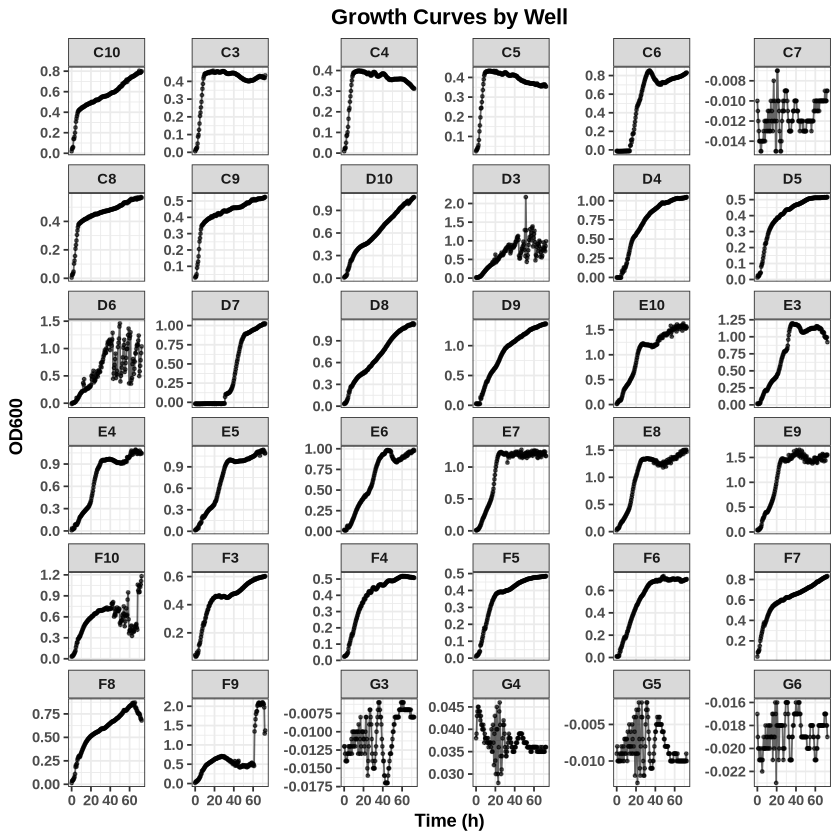

In [18]:
# Plot each well individually
well_plot <- ggplot(od_long2, aes(x = Time, y = OD600)) +
  geom_point(size = 0.7, alpha = 0.6) +
  geom_line(alpha = 0.6) +
  facet_wrap(~well, scales = "free_y") +
  labs(
    x = "Time (h)",
    y = "OD600",
    title = "Growth Curves by Well"
  ) +
  # scale_y_continuous(limits = c(-0.1, 2)) +
  theme_bw() +
  theme(
    text = element_text(face = "bold"),            # all text bold
    strip.text = element_text(face = "bold"),      # facet labels bold
    axis.title = element_text(face = "bold"),      # axis titles bold
    axis.text = element_text(face = "bold"),       # axis numbers bold
    plot.title = element_text(face = "bold", hjust = 0.5) # center + bold title
  )
well_plot

In [27]:
# Drop blank rows
od_long3 <- od_long2 %>%
  filter(strain != "Blank", 
         carbon_source != "Blank", 
         !well %in% c("C6","C7", "D7", 
                      "D3", "D6", "E10", "F10", "F3", "F9")) # Remove wells that are too weird

head(od_long3)

Time,well,OD600,strain,carbon_source,OD600_corrected
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
0,C3,0.006,1253,CLM_GLU,0.005994863
0,C4,0.009,1253,CLM_GLU,0.008994863
0,C5,0.025,1253,CLM_GLU,0.024994863
0,C8,0.005,1956,CLM_GLU,0.004994863
0,C9,0.031,1956,CLM_GLU,0.030994863
0,C10,0.020,1956,CLM_GLU,0.019994863


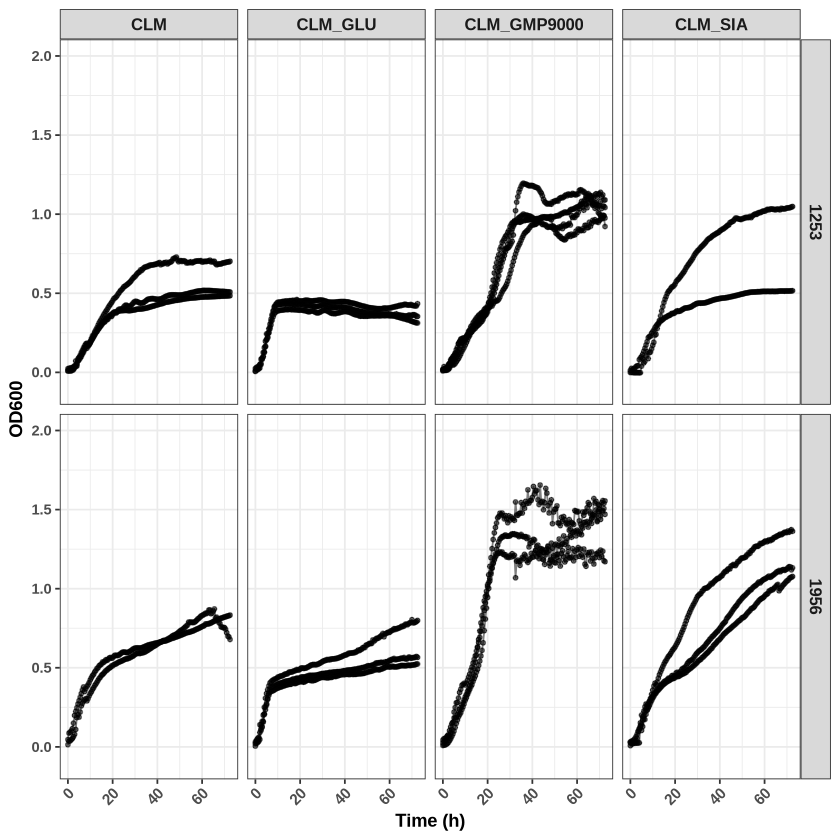

In [28]:
# Plot per carbon source and strain
growth_plot <- ggplot(od_long3, aes(x = Time, y = OD600_corrected, group = well)) +
  geom_point(size = 1, alpha = 0.6) +       # raw measurements
  geom_line(alpha = 0.5) +                  # connect points per well
  facet_grid(strain ~ carbon_source, scales = "free_y") +  # rows = Strain, cols = Carbon
  labs(
    x = "Time (h)",
    y = "OD600") +
  scale_y_continuous(limits = c(-0.1, 2)) +  # fix y-axis across all facets
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", hjust = 0.5),
    strip.text = element_text(size = 10, face = "bold"),
    legend.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold")
  )

growth_plot

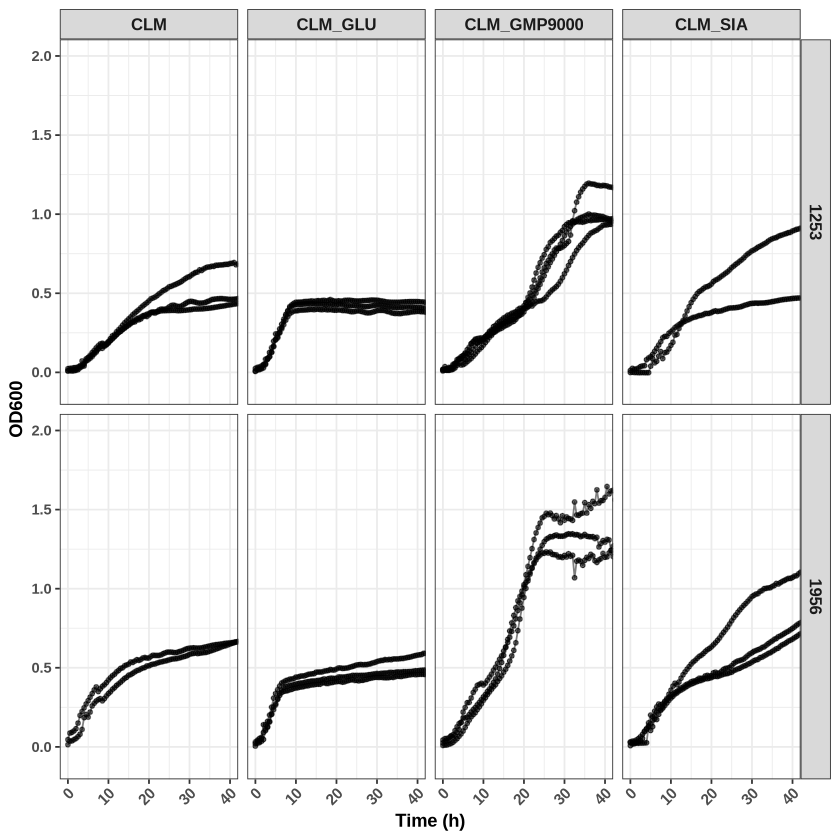

In [29]:
# Plot per carbon source and strain
growth_plot <- ggplot(od_long3, aes(x = Time, y = OD600_corrected, group = well)) +
  geom_point(size = 1, alpha = 0.6) +       # raw measurements
  geom_line(alpha = 0.5) +                  # connect points per well
  facet_grid(strain ~ carbon_source, scales = "free_y") +  # rows = Strain, cols = Carbon
  labs(
    x = "Time (h)",
    y = "OD600") +
  scale_y_continuous(limits = c(-0.1, 2)) +  # fix y-axis across all facets
  coord_cartesian(xlim = c(0, 40)) +   # <- limits to 0–40h but keeps smoothing intact
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", hjust = 0.5),
    strip.text = element_text(size = 10, face = "bold"),
    legend.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold")
  )

growth_plot

`geom_smooth()` using formula = 'y ~ x'


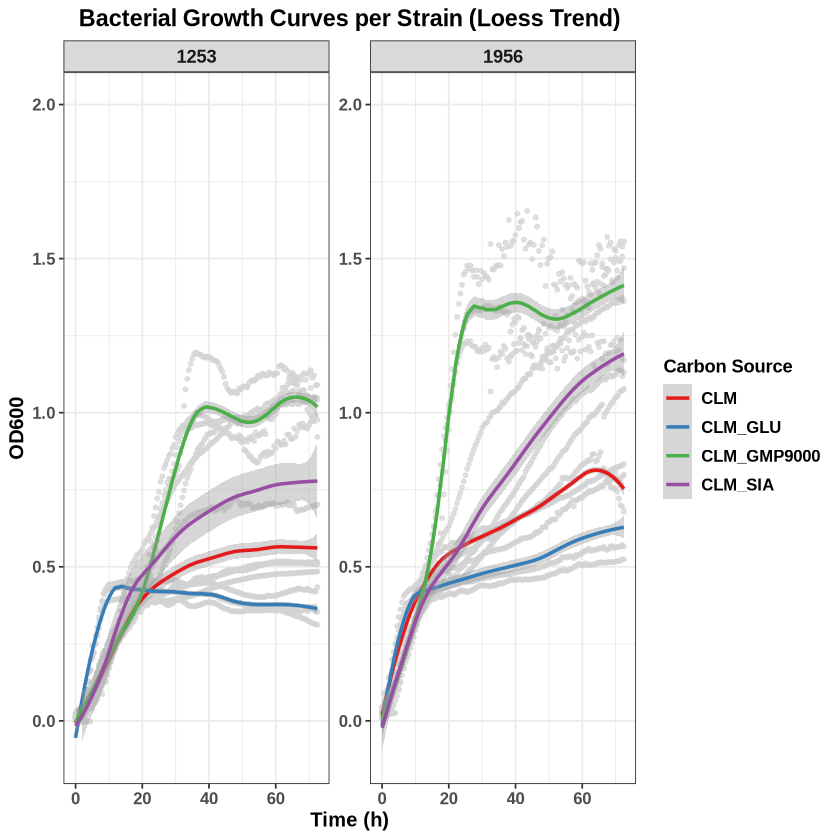

In [32]:
plot <- ggplot(od_long3, aes(x = Time, y = OD600_corrected)) +
  # Raw measurements in light gray
  geom_point(aes(group = well), color = "lightgray", size = 1.0, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = carbon_source, group = carbon_source), 
              method = "loess", span = 0.3, se = TRUE, size = 1) +
  facet_wrap(~strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Trend)"
  ) +
  scale_y_continuous(limits = c(-0.1, 2)) +  # fix y-axis across all facets
  # coord_cartesian(xlim = c(0, 40)) +   # <- limits to 0–40h but keeps smoothing intact
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5) # centered bold title
  )

plot

`geom_smooth()` using formula = 'y ~ x'


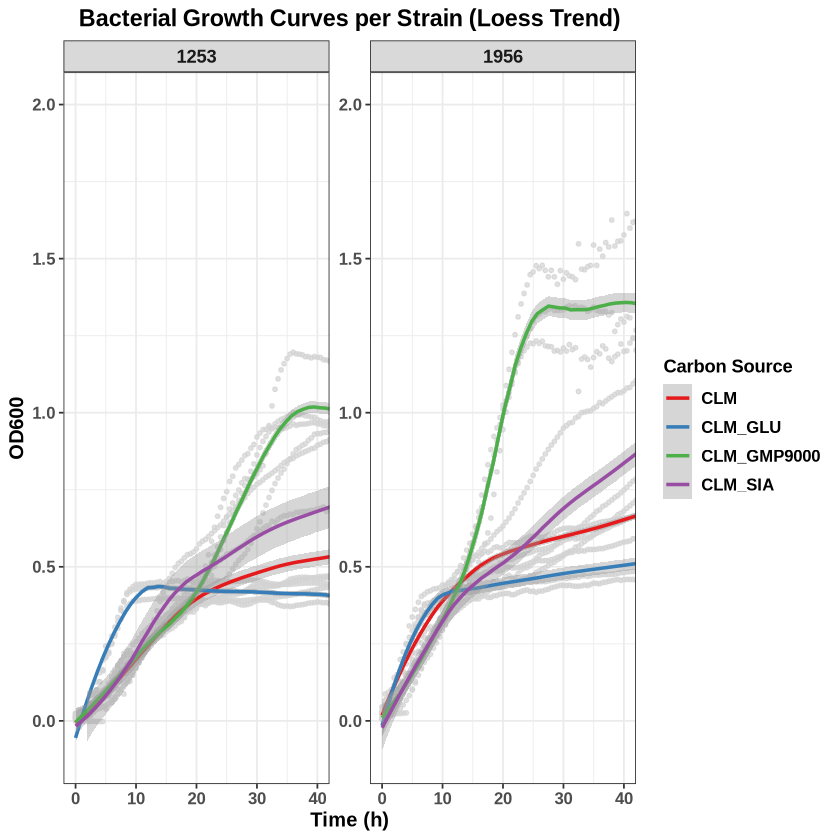

In [33]:
plot <- ggplot(od_long3, aes(x = Time, y = OD600_corrected)) +
  # Raw measurements in light gray
  geom_point(aes(group = well), color = "lightgray", size = 1.0, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = carbon_source, group = carbon_source), 
              method = "loess", span = 0.3, se = TRUE, size = 1) +
  facet_wrap(~strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Trend)"
  ) +
  scale_y_continuous(limits = c(-0.1, 2)) +  # fix y-axis across all facets
  coord_cartesian(xlim = c(0, 40)) +   # <- limits to 0–40h but keeps smoothing intact
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5) # centered bold title
  )

plot

In [235]:
ggsave("aureus_CLM_OX_010925.png", plot = plot, width = 10, height = 8)

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


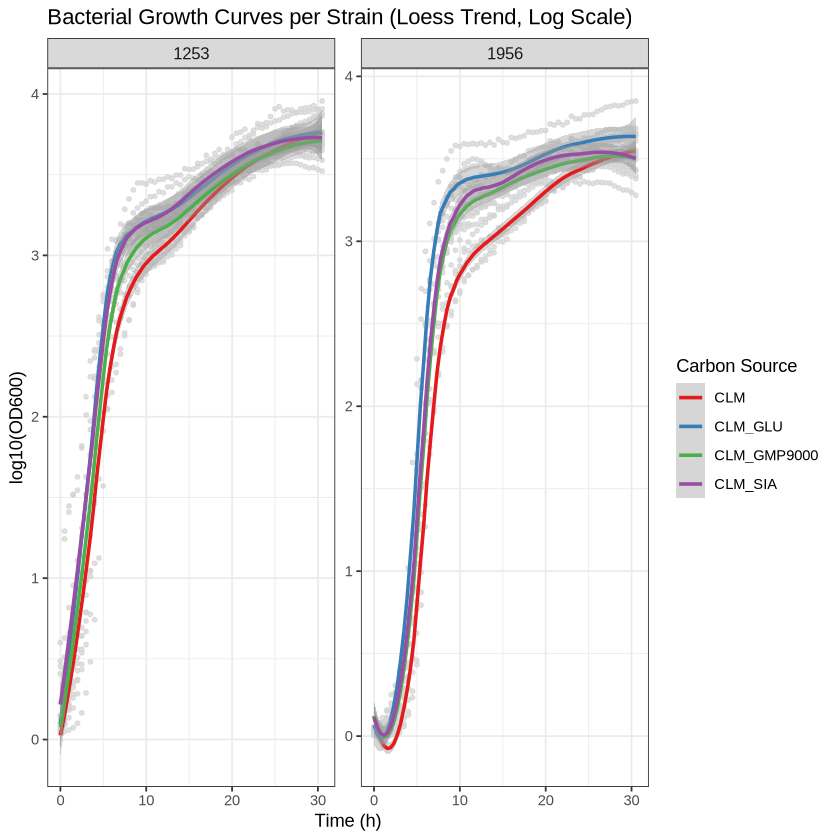

In [27]:
# Plot y-axis in log scale
ggplot(od_long3, aes(x = Time, y = OD600_corrected)) +
  geom_point(aes(group = well), color = "lightgray", size = 1.0, alpha = 0.7) +
  geom_smooth(aes(color = carbon_source, group = carbon_source),
              method = "loess", span = 0.3, se = TRUE, size = 1) +
  facet_wrap(~strain, scales = "free_y") +
  # scale_y_log10(limits = c(0.01, 2)) +   # <-- log10 axis, set sensible limits
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "log10(OD600)",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Trend, Log Scale)"
  ) +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [231]:
# Remove CLM_GMP9000 rows
od_long_no_gmp <- od_long3 %>%
  filter(carbon_source != "CLM_GMP9000")
head(od_long_no_gmp)

Time,well,OD600,strain,carbon_source,OD600_corrected
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
0,C3,0.060,1253,CLM_GLU,0.05999486
0,C4,0.094,1253,CLM_GLU,0.09399486
0,C5,0.053,1253,CLM_GLU,0.05299486
0,C6,0.090,1253,CLM_GLU,0.08999486
0,C7,0.093,1956,CLM_GLU,0.09299486
0,C8,0.087,1956,CLM_GLU,0.08699486


`geom_smooth()` using formula = 'y ~ x'


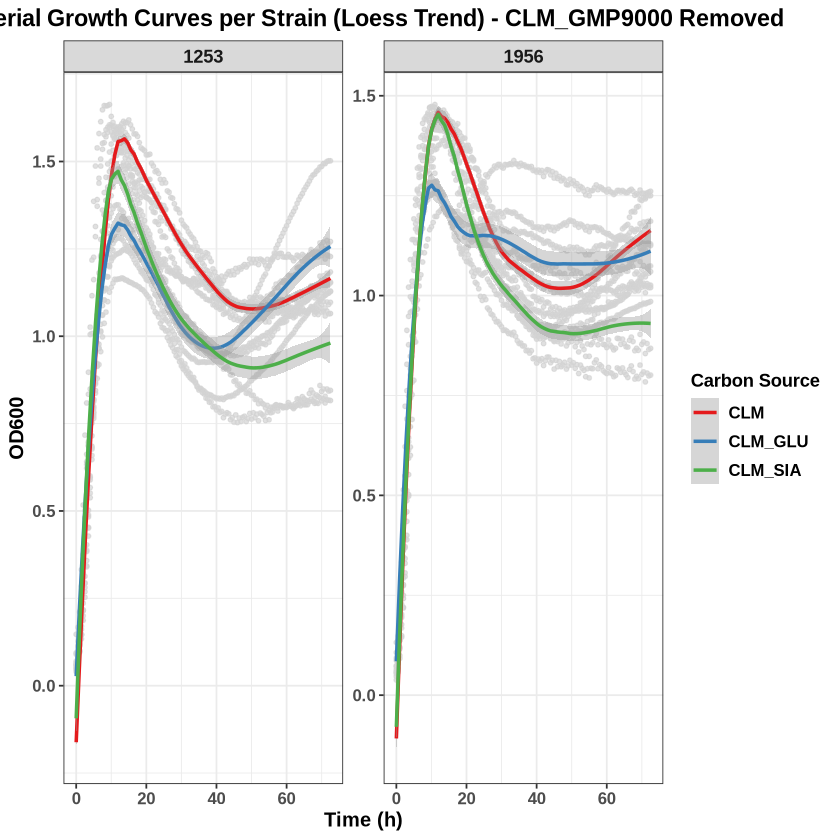

In [233]:
plot_no_gmp <- ggplot(od_long_no_gmp, aes(x = Time, y = OD600_corrected)) +
  # Raw measurements in light gray
  geom_point(aes(group = well), color = "lightgray", size = 1.0, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = carbon_source, group = carbon_source), 
              method = "loess", span = 0.3, se = TRUE, size = 1) +
  facet_wrap(~strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "Bacterial Growth Curves per Strain (Loess Trend) - CLM_GMP9000 Removed"
  ) +
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plot_no_gmp

In [236]:
ggsave("aureus_CLM_OX_010925_noGMP.png", plot = plot_no_gmp, width = 10, height = 8)

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


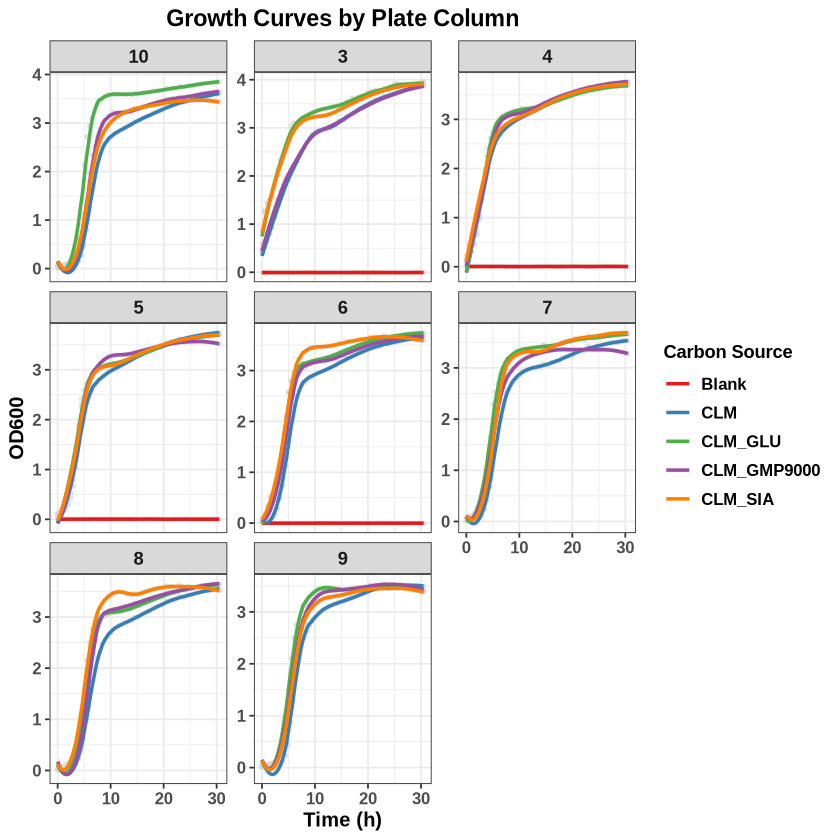

In [29]:
# Create a column identifier (numeric part of well name = column)
od_long3 <- od_long2 %>%
  mutate(column = str_extract(well, "\\d+"))

# Plot grouped by column
plot_col <- ggplot(od_long3, aes(x = Time, y = OD600_corrected)) +
  # Raw well-level data in light gray
  geom_point(aes(group = well), color = "lightgray", size = 0.8, alpha = 0.6) +
  # Loess trend per column (colored by carbon source for clarity)
  geom_smooth(aes(color = carbon_source, group = interaction(column, carbon_source)), 
              method = "loess", span = 0.3, se = FALSE, size = 1) +
  facet_wrap(~column, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "Growth Curves by Plate Column"
  ) +
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plot_col